**Every-visit Monte-Carlo**

In this exercise, we are going to implement the every-visit Monte-Carlo algorithm in the next MDP, which is a Random Walk:

![alt text](rw.png "Title")

Let us start with the imports. We use only numpy in this exercise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

The next thing we do is to seed the random number generator.This is done to ensure that the results are reproducible.At this point, this is not strictly necessary, but it is good practice to do so (and when working with Deep Reinforcement Learning, it is absolutely necessary).

In [2]:
rng = np.random.default_rng(1234)

Now, let us define the parameters of the problem. We have an MDP with seven states (two of which are terminal states), and two actions. The rewards, discount factor, and transition probabilities are given in the figure above. For this case, we only evaluate one policy: the uniform random policy, which assigns equal probability to all actions in all states.

In [3]:
gamma = 0.9
R = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]]).T
P = np.array([[1, 0, 0, 0, 0, 0, 0],
              [1, 0, 0, 0, 0, 0, 0],
              [0, 0, 1, 0, 0, 0, 0],
              [1, 0, 0, 0, 0, 0, 0],
              [0, 0, 0, 1, 0, 0, 0],
              [0, 1, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 1, 0, 0],
              [0, 0, 1, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 1, 0],
              [0, 0, 0, 1, 0, 0, 0],
              [0, 0, 0, 0, 0, 0, 1],
              [0, 0, 0, 0, 1, 0, 0],
              [0, 0, 0, 0, 0, 0, 1],
              [0, 0, 0, 0, 0, 0, 1]])
pi = np.array([[0.5, 0.5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
               [0, 0, 0.5, 0.5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
               [0, 0, 0, 0, 0.5, 0.5, 0, 0, 0, 0, 0, 0, 0, 0],
               [0, 0, 0, 0, 0, 0, 0.5, 0.5, 0, 0, 0, 0, 0, 0],
               [0, 0, 0, 0, 0, 0, 0, 0, 0.5, 0.5, 0, 0, 0, 0],
               [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.5, 0.5, 0, 0],
               [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.5, 0.5]])

Now, let us implement the every-visit version of the Monte-Carlo method to estimate the value function of the policy $\pi$. You should obtain a similar value function $v^\pi$ to the one provided.

In [23]:
n_states = 7
n_actions = 2
n_s = np.zeros((n_states, 1))

threshold = 1e-4  # Variation change for convergence check in VI
i = 0  # VI iterations
delta = 1.0  # Initial difference value
v_mc = [np.zeros((n_states, 1))]  # Randomly initiate the value function
min_iters = 100  # Set a minimum set of MC iterations: as the reward is sparse, it may (wrongly) converge in the first iterations, if the first episode only has zero rewards

converged = False
Returns_s = [[] for _ in range(n_states)]

def step(a):
    done = False
    # Elegir índice de transición según pi
    next_index = np.random.choice(np.arange(14), p=a)
    # Obtener siguiente estado real
    next_s = np.random.choice(np.arange(7),p=P[next_index])
    # Recompensa
    r = R[next_index,0]

    if next_s == 6 or next_s == 0:
        done = True

    return next_s, r, done

while not converged:
    delta = 0
    next_state = 3  # Fixed initial state

    # To be filled by the student
    episode = []
    s = next_state
    done = False
    while not done:

    # select an action according to policy pi
        a = pi[s]  
        # step in the environment
        next_s, r, done = step(a)
        episode.append((s, r))
        s = next_s 

    v_mc.append(v_mc[-1].copy())
    G = 0
    for t in reversed(range(len(episode))):
        s, r = episode[t]
        G = r + gamma * G
        Returns_s[s].append(G) # Reward de cada estado.
        v_mc[-1][s] = np.mean(Returns_s[s])
        delta = max(delta, abs(v_mc[-1][s] - v_mc[-2][s]))

    i += 1
    converged = (delta < threshold) and (i > min_iters)

print(f"Every-visit Monte-Carlo has converged after {i} iterations")

with np.printoptions(precision=2, suppress=True):
    print(f"v^pi MC = {v_mc[-1].flatten()}") 


Every-visit Monte-Carlo has converged after 859 iterations
v^pi MC = [0.   0.06 0.15 0.26 0.42 0.68 0.  ]


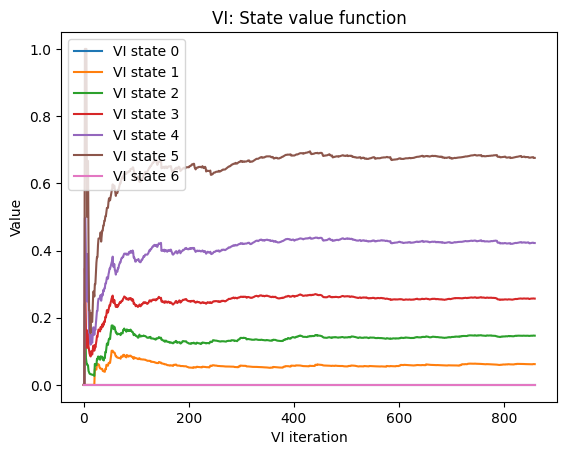

In [25]:
for s in range(n_states):
    plt.plot([v[s] for v in v_mc], label='VI state ' + str(s)) 
plt.legend(loc='best') 
plt.xlabel('VI iteration') 
plt.ylabel('Value') 
plt.title('VI: State value function') 
plt.show()